In [ ]:
import kagglehub
import os # Import os module

# Download latest version
path = kagglehub.dataset_download("nirmalsankalana/plantdoc-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'plantdoc-dataset' dataset.
Path to dataset files: /kaggle/input/plantdoc-dataset
Contents of base_path (/kaggle/input):
['plantdoc-dataset']
Contents of path (/kaggle/input/plantdoc-dataset):
['folder_renamer.py', 'file_renamer.py', 'test', 'train']


In [ ]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs detected.")
        print("GPU is available and active.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU detected. Using CPU.")

1 Physical GPUs, 1 Logical GPUs detected.
GPU is available and active.


## Data Loading and Preprocessing

First, let's determine the dataset directory structure from the `path` variable provided by KaggleHub. We will then load the image data using `tf.keras.utils.image_dataset_from_directory` and apply basic preprocessing.

In [ ]:
# Assume 'path' from the previous cell contains the downloaded dataset.
# We need to find the actual dataset folder name inside 'path'.

# The previous logic incorrectly identified a subfolder (like 'test') as the dataset_root.
# Based on the output of the previous cell, 'path' itself is the root directory
# containing 'train', 'test', and potentially 'valid' subdirectories.
dataset_root = path

print(f"Dataset root directory: {dataset_root}")
print(f"Contents of dataset_root ({dataset_root}):\n{os.listdir(dataset_root)}")

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Constants for dataset splitting
VALIDATION_SPLIT = 0.2
SEED = 42 # Important for reproducible split

# Load training data, splitting a portion for validation
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_root, 'train'),
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT, # Specify validation split
    subset='training', # This is the training subset
    seed=SEED # Important for reproducible split
)

# Load validation data from the same 'train' directory
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_root, 'train'), # Use the 'train' folder
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False, # No need to shuffle validation data when split from training
    validation_split=VALIDATION_SPLIT, # Specify validation split
    subset='validation', # This is the validation subset
    seed=SEED # Important for reproducible split
)

# Load test data
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_root, 'test'),
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get the number of classes (from the training dataset)
num_classes = len(train_ds.class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {train_ds.class_names}")

# Standardize images to [0, 1] range
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Data loading and preprocessing complete.")

Dataset root directory: /kaggle/input/plantdoc-dataset
Contents of dataset_root (/kaggle/input/plantdoc-dataset):
['folder_renamer.py', 'file_renamer.py', 'test', 'train']
Found 2670 files belonging to 28 classes.
Using 2136 files for training.
Found 2670 files belonging to 28 classes.
Using 534 files for validation.
Found 252 files belonging to 27 classes.
Number of classes: 28
Class names: ['Apple_Scab_Leaf', 'Apple_leaf', 'Apple_rust_leaf', 'Bell_pepper_leaf', 'Bell_pepper_leaf_spot', 'Blueberry_leaf', 'Cherry_leaf', 'Corn_Gray_leaf_spot', 'Corn_leaf_blight', 'Corn_rust_leaf', 'Peach_leaf', 'Potato_leaf_early_blight', 'Potato_leaf_late_blight', 'Raspberry_leaf', 'Soyabean_leaf', 'Squash_Powdery_mildew_leaf', 'Strawberry_leaf', 'Tomato_Early_blight_leaf', 'Tomato_Septoria_leaf_spot', 'Tomato_leaf', 'Tomato_leaf_bacterial_spot', 'Tomato_leaf_late_blight', 'Tomato_leaf_mosaic_virus', 'Tomato_leaf_yellow_virus', 'Tomato_mold_leaf', 'Tomato_two_spotted_spider_mites_leaf', 'grape_leaf', '

## Build Inception Model

We will use a pre-trained InceptionV3 model as a base and add a custom classification head for our specific task. The base layers will be frozen during initial training.

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load the InceptionV3 model with pre-trained ImageNet weights
base_model = InceptionV3(
    weights='imagenet',
    include_top=False, # Do not include the ImageNet classifier at the top
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze the base model layers
base_model.trainable = False

# Create the custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x) # Global average pooling to flatten the output
x = Dense(1024, activation='relu')(x) # Add a fully connected layer
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(num_classes, activation='softmax')(x) # Output layer for classification

# Combine base model and new head
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("InceptionV3 model built and compiled.")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 23,929,660 (91.28 MB)

 Trainable params: 2,126,876 (8.11 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

InceptionV3 model built and compiled.


## Train the Inception Model

Now, let's train the model using our prepared datasets. We'll train for a few epochs initially.

In [ ]:
EPOCHS = 10 # You can adjust this number

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

print("Model training complete.")

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 65s 746ms/step - accuracy: 0.1774 - loss: 3.0422 - val_accuracy: 0.4007 - val_loss: 2.3893
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.3450 - loss: 2.3569 - val_accuracy: 0.4682 - val_loss: 1.9969
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.4167 - loss: 2.0198 - val_accuracy: 0.5375 - val_loss: 1.7760
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.4761 - loss: 1.7904 - val_accuracy: 0.5637 - val_loss: 1.6250
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.5318 - loss: 1.6107 - val_accuracy: 0.6199 - val_loss: 1.4462
Epoch 6/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.5632 - loss: 1.4538 - val_accuracy: 0.6685 - val_loss: 1.3089
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.6077 - loss: 1.3314 - val_accuracy: 0.6891 - val_loss: 1.2215
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.6479 - loss: 1.1949 - val_accuracy: 0.6985 -

## Summarize Training Results

Let's evaluate the model's performance on the test set and display the training metrics.

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Display training history
print("\nTraining History:")
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}:")
    print(f"  Loss: {history.history['loss'][epoch]:.4f}, Accuracy: {history.history['accuracy'][epoch]:.4f}")
    print(f"  Val Loss: {history.history['val_loss'][epoch]:.4f}, Val Accuracy: {history.history['val_accuracy'][epoch]:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3968 - loss: 2.2157

Test Loss: 2.2157
Test Accuracy: 0.3968

Training History:
Epoch 1:
  Loss: 3.0422, Accuracy: 0.1774
  Val Loss: 2.3893, Val Accuracy: 0.4007
Epoch 2:
  Loss: 2.3569, Accuracy: 0.3450
  Val Loss: 1.9969, Val Accuracy: 0.4682
Epoch 3:
  Loss: 2.0198, Accuracy: 0.4167
  Val Loss: 1.7760, Val Accuracy: 0.5375
Epoch 4:
  Loss: 1.7904, Accuracy: 0.4761
  Val Loss: 1.6250, Val Accuracy: 0.5637
Epoch 5:
  Loss: 1.6107, Accuracy: 0.5318
  Val Loss: 1.4462, Val Accuracy: 0.6199
Epoch 6:
  Loss: 1.4538, Accuracy: 0.5632
  Val Loss: 1.3089, Val Accuracy: 0.6685
Epoch 7:
  Loss: 1.3314, Accuracy: 0.6077
  Val Loss: 1.2215, Val Accuracy: 0.6891
Epoch 8:
  Loss: 1.1949, Accuracy: 0.6479
  Val Loss: 1.1345, Val Accuracy: 0.6985
Epoch 9:
  Loss: 1.0980, Accuracy: 0.6807
  Val Loss: 1.0474, Val Accuracy: 0.7210
Epoch 10:
  Loss: 1.0180, Accuracy: 0.7097
  Val Loss: 1.0624, Val Accuracy: 0.7116


## Display Training Plots

Visualize the training and validation accuracy and loss over epochs to understand the model's learning progress.

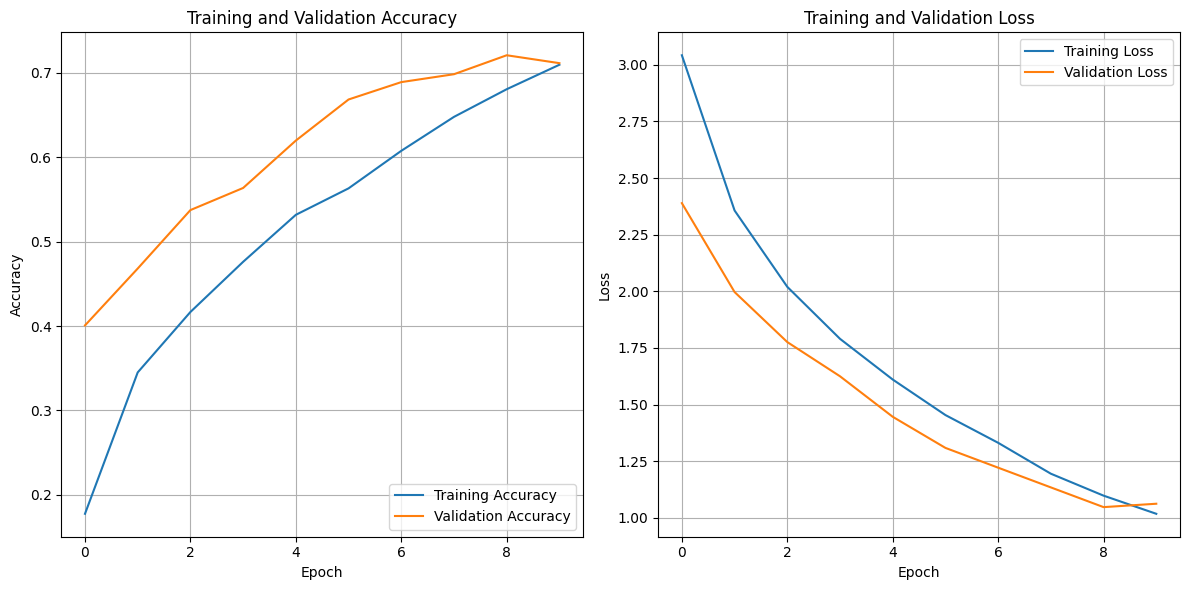

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()